# MNIST Digit Recognizer: Reproducibility & Setup

## Environment Setup

To reproduce the results in this notebook, follow these steps:

### 1. Create a Conda Environment (Recommended)
```bash
conda env create -f environment.yml
conda activate foml
```

### 2. Or Install Dependencies Manually
```bash
pip install torch torchvision --index-url https://download.pytorch.org/whl/cpu
pip install scikit-learn pandas numpy matplotlib seaborn tqdm
```

### 3. Download Dataset
- Download the MNIST dataset from Kaggle: [digit-recognizer](https://www.kaggle.com/competitions/digit-recognizer)
- Extract `train.csv` and `test.csv` into the same directory as this notebook
- The dataset should contain:
  - `train.csv`: 42,000 samples with labels (column 0 = label, columns 1-784 = pixel values 0-255)
  - `test.csv`: 28,000 samples without labels (columns 1-784 = pixel values)

### 4. Run the Notebook
```bash
jupyter notebook program.ipynb
```

Execute cells **sequentially** from top to bottom. The notebook trains and saves models, so some cells may take a few minutes.

## Key Libraries & Versions
- **PyTorch**: 2.0+ (for neural networks)
- **scikit-learn**: 1.3+ (for SVM, PCA, grid search)
- **pandas**: 1.5+ (for data handling)
- **numpy**: 1.24+ (for numerical operations)
- **matplotlib & seaborn**: for visualization


In [95]:
# Import necessary libraries
import numpy as np
import pandas as pd
import seaborn as sns
import torch.nn as nn
import matplotlib.pyplot as plt

In [96]:
# Load the data
print("Loading dataset...")
df = pd.read_csv("train.csv")

# Separate labels from pixel features
y = df['label']
X = df.drop('label', axis=1)

print(f"Dataset loaded! Total images: {len(X)}")
print(f"Number of features (pixels) per image: {X.shape[1]}")

Loading dataset...
Dataset loaded! Total images: 42000
Number of features (pixels) per image: 784


In [97]:
import os

FIG_DIR = os.path.join(os.getcwd(), 'report', 'final_figures')
TEX_DIR = os.path.join(os.getcwd(), 'report', 'final_tex')
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(TEX_DIR, exist_ok=True)

def save_tex(filename, content):
    path = os.path.join(TEX_DIR, filename)
    with open(path, 'w') as f:
        f.write(content)
    print(f"Saved TeX: {path}")

print(f"Figures → {FIG_DIR}")
print(f"LaTeX   → {TEX_DIR}")

Figures → /home/priyank1/FOML/project/FOML/report/final_figures
LaTeX   → /home/priyank1/FOML/project/FOML/report/final_tex


## Step 1: Exploratory Data Analysis (EDA)

In this section, we will load the Kaggle MNIST dataset and visualize it to understand the distribution of our classes and the natural variance in human handwriting.

/tmp/ipykernel_3879042/1985869958.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y, palette="viridis")


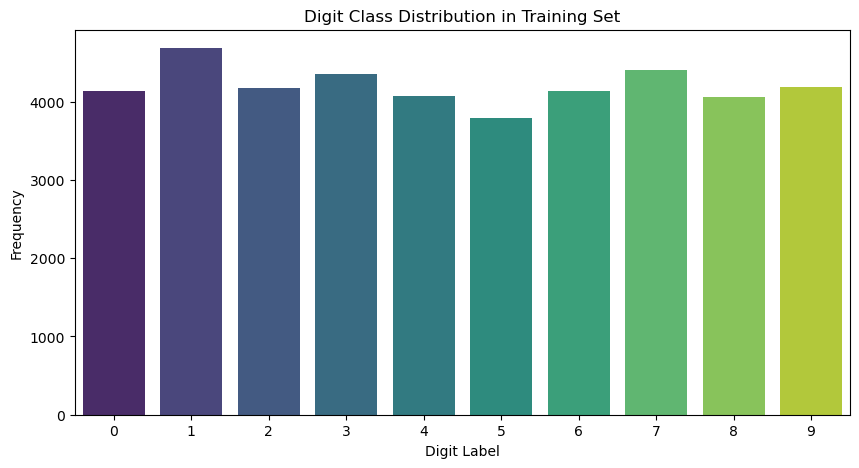

In [98]:
plt.figure(figsize=(10, 5))
sns.countplot(x=y, palette="viridis")
plt.title("Digit Class Distribution in Training Set")
plt.xlabel("Digit Label")
plt.ylabel("Frequency")
plt.savefig(os.path.join(FIG_DIR, 'class_distribution.pdf'), bbox_inches='tight')
plt.show()

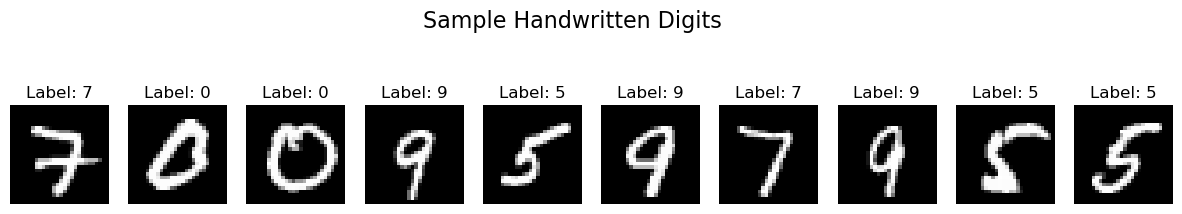

In [99]:
plt.figure(figsize=(15, 3))

num_digits = 10
random_indices = np.random.randint(0, len(X), num_digits)

for i, idx in enumerate(random_indices):
    plt.subplot(1, num_digits, i + 1)
    image = X.iloc[idx].values.reshape(28, 28)
    plt.imshow(image, cmap='gray')
    plt.title(f"Label: {y.iloc[idx]}")
    plt.axis('off')

plt.suptitle("Sample Handwritten Digits", fontsize=16)
plt.savefig(os.path.join(FIG_DIR, 'sample_digits.pdf'), bbox_inches='tight')
plt.show()

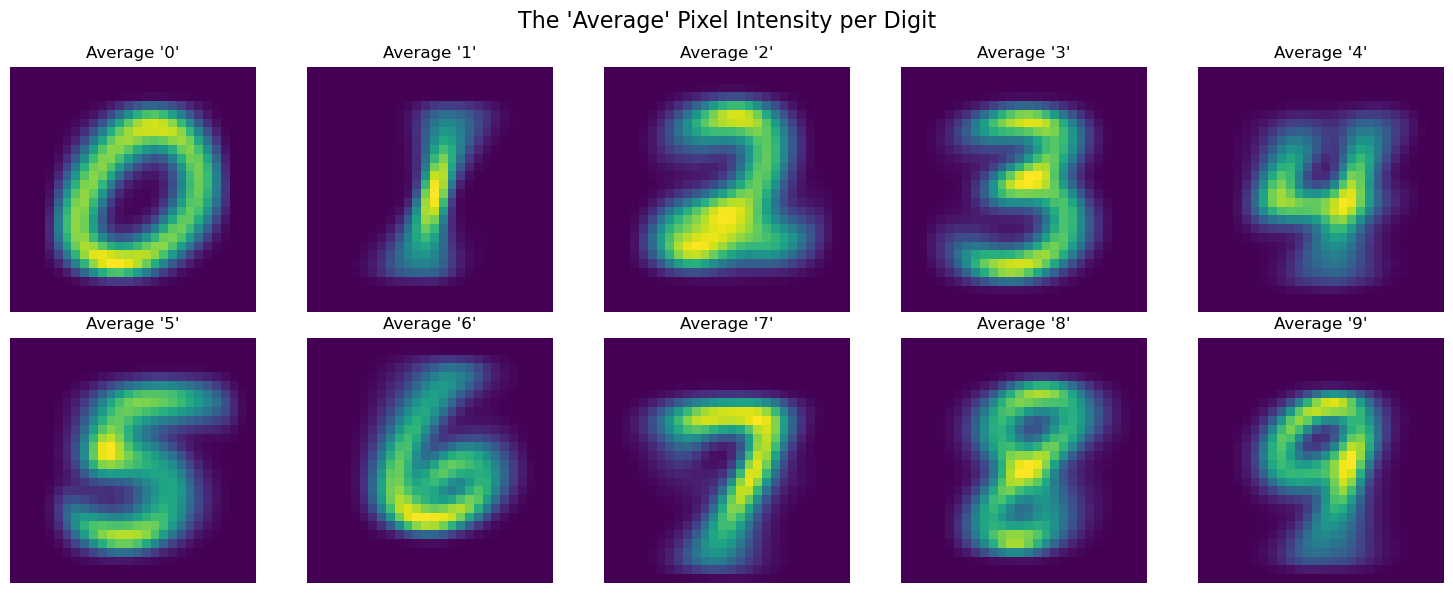

In [100]:
plt.figure(figsize=(15, 6))

for digit in range(10):
    digit_data = X[y == digit]
    avg_image = digit_data.mean(axis=0).values.reshape(28, 28)
    plt.subplot(2, 5, digit + 1)
    plt.imshow(avg_image, cmap='viridis')
    plt.title(f"Average '{digit}'")
    plt.axis('off')

plt.suptitle("The 'Average' Pixel Intensity per Digit", fontsize=16)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'average_digits.pdf'), bbox_inches='tight')
plt.show()

## Step 2: Feature Processing & Engineering

Before feeding our images into an algorithm, we need to optimize the data. 
1. **Normalization:** Machine learning models (especially SVMs and Neural Networks) struggle with large numbers. We will scale our pixel values from `0 - 255` down to `0.0 - 1.0`.
2. **Dimensionality Reduction (PCA):** Images have 784 pixels (features), but many of these pixels are completely useless (like the black edges of the image where nobody writes). We will use Principal Component Analysis to compress the data into fewer, more meaningful features.

In [101]:
# 1. Normalization (Scaling)
print("Normalizing pixel values")
# Dividing by 255 scales all values to be between 0 and 1
X_scaled = X / 255.0

print(f"Max pixel value before: {X.iloc[0].max()}")
print(f"Max pixel value after: {X_scaled.iloc[0].max()}")

Normalizing pixel values
Max pixel value before: 255
Max pixel value after: 1.0


### 2.1 Analyzing Principal Components
Let's fit PCA on our data and plot the **Cumulative Explained Variance**. This will show us exactly how many components we need to retain, say, 95% of the visual information.

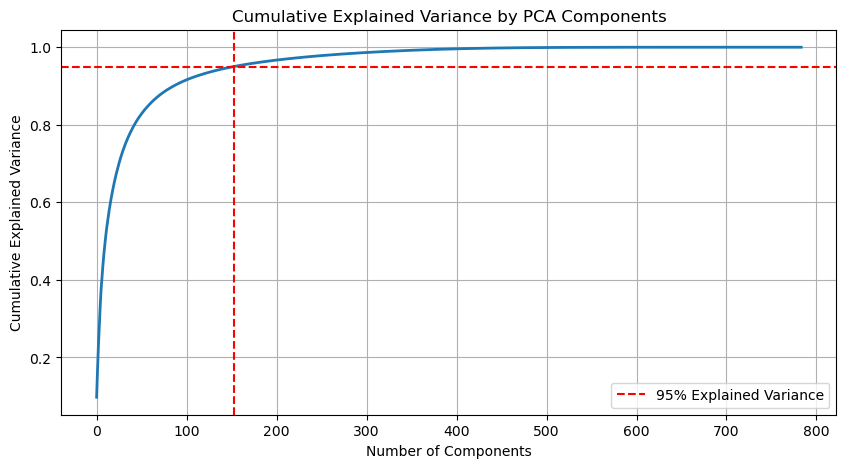

To keep 95% of the information, we only need 154 components (down from 784!)


In [102]:
from sklearn.decomposition import PCA

pca_full = PCA()
pca_full.fit(X_scaled)

cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure(figsize=(10, 5))
plt.plot(cumulative_variance, linewidth=2)
plt.axhline(y=0.95, color='r', linestyle='--', label='95% Explained Variance')
plt.axvline(x=np.argmax(cumulative_variance >= 0.95), color='r', linestyle='--')
plt.title('Cumulative Explained Variance by PCA Components')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.grid(True)
plt.legend()
plt.savefig(os.path.join(FIG_DIR, 'pca_variance.pdf'), bbox_inches='tight')
plt.show()

n_components_95 = np.argmax(cumulative_variance >= 0.95)
print(f"To keep 95% of the information, we only need {n_components_95 + 1} components (down from 784!)")

### 2.2 Applying PCA and Visualizing the Reconstruction
The chart above shows a massive mathematical shortcut! We can throw away over 600 pixels and still keep 95% of the core shapes. 

Let's apply this compression. To prove to ourselves that the model can still "see" the digits, we will reconstruct an image from the compressed data and compare it to the original.

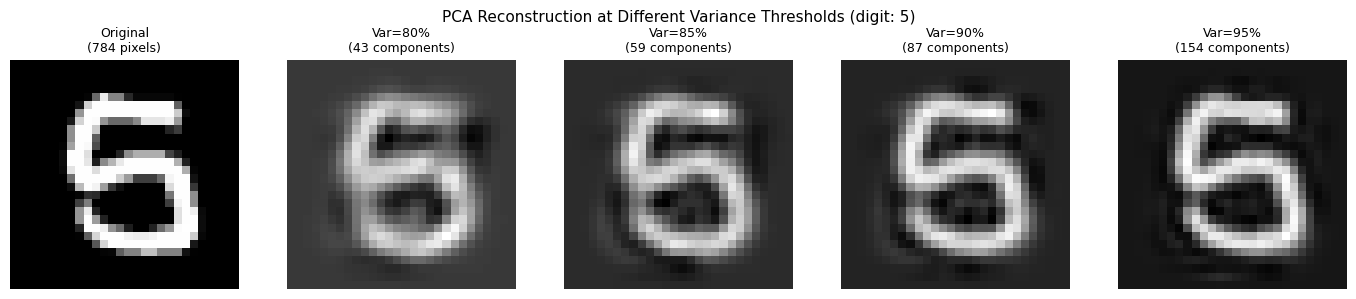

Saved pca_reconstruction.pdf


In [103]:
import matplotlib
matplotlib.use('Agg')
%matplotlib inline

from sklearn.decomposition import PCA

VARIANCE_THRESHOLDS = [0.80, 0.85, 0.90, 0.95]
SAMPLE_INDEX = 51

original_image = X_scaled.iloc[SAMPLE_INDEX].values

fig, axes = plt.subplots(1, len(VARIANCE_THRESHOLDS) + 1, figsize=(14, 3))

axes[0].imshow(original_image.reshape(28, 28), cmap='gray')
axes[0].set_title('Original\n(784 pixels)', fontsize=9)
axes[0].axis('off')

for i, var in enumerate(VARIANCE_THRESHOLDS):
    pca_v = PCA(n_components=var, random_state=42)
    X_pca_v = pca_v.fit_transform(X_scaled)
    n_comp = X_pca_v.shape[1]
    X_recon = pca_v.inverse_transform(X_pca_v)
    recon_img = X_recon[SAMPLE_INDEX].reshape(28, 28)
    axes[i + 1].imshow(recon_img, cmap='gray')
    axes[i + 1].set_title(f'Var={var:.0%}\n({n_comp} components)', fontsize=9)
    axes[i + 1].axis('off')

plt.suptitle(f'PCA Reconstruction at Different Variance Thresholds (digit: {y.iloc[SAMPLE_INDEX]})', fontsize=11)
plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'pca_reconstruction.pdf'), bbox_inches='tight')
plt.show()
print("Saved pca_reconstruction.pdf")

## Step 3: Logistic Regression (Baseline Classifier)

Using the scaled + PCA-reduced features (95% variance threshold) as input to a simple logistic regression model.

In [104]:
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

# PCA with 95% variance
pca = PCA(n_components=0.95, random_state=42)
X_pca = pca.fit_transform(X_scaled)
print(f"PCA reduced features: 784 → {X_pca.shape[1]} components")

# Train / val / test split (60 / 20 / 20)
X_train, X_temp, y_train, y_temp = train_test_split(X_pca, y, test_size=0.4, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)
print(f"Split sizes — train: {len(X_train)}, val: {len(X_val)}, test: {len(X_test)}")

# Logistic Regression
lr = LogisticRegression(max_iter=1000, solver='lbfgs', multi_class='multinomial', random_state=42)
lr.fit(X_train, y_train)

# Validation accuracy
y_val_pred = lr.predict(X_val)
val_acc = accuracy_score(y_val, y_val_pred)
print(f"\nValidation Accuracy: {val_acc:.4f} ({val_acc*100:.2f}%)")

# Test accuracy
y_test_pred = lr.predict(X_test)
test_acc = accuracy_score(y_test, y_test_pred)
print(f"Test Accuracy:       {test_acc:.4f} ({test_acc*100:.2f}%)")
print("\nClassification Report (Test Set):")
print(classification_report(y_test, y_test_pred))

# ── Save LaTeX classification report ──────────────────────────────────────────
report_dict = classification_report(y_test, y_test_pred, output_dict=True)
rows = "\n".join(
    f"  {lbl} & {report_dict[lbl]['precision']:.4f} & {report_dict[lbl]['recall']:.4f} "
    f"& {report_dict[lbl]['f1-score']:.4f} & {int(report_dict[lbl]['support'])} \\\\"
    for lbl in [str(i) for i in range(10)]
)
tex = (
    "\\begin{tabular}{lcccc}\n\\toprule\n"
    "Class & Precision & Recall & F1-Score & Support \\\\\n\\midrule\n"
    + rows + "\n\\midrule\n"
    f"  macro avg & {report_dict['macro avg']['precision']:.4f} & {report_dict['macro avg']['recall']:.4f} "
    f"& {report_dict['macro avg']['f1-score']:.4f} & {int(report_dict['macro avg']['support'])} \\\\\n"
    f"  weighted avg & {report_dict['weighted avg']['precision']:.4f} & {report_dict['weighted avg']['recall']:.4f} "
    f"& {report_dict['weighted avg']['f1-score']:.4f} & {int(report_dict['weighted avg']['support'])} \\\\\n"
    f"\\midrule\n  Accuracy & \\multicolumn{{3}}{{c}}{{{test_acc:.4f}}} & {int(report_dict['weighted avg']['support'])} \\\\\n"
    "\\bottomrule\n\\end{tabular}"
)
save_tex('lr_classification_report.tex', tex)

PCA reduced features: 784 → 154 components
Split sizes — train: 25200, val: 8400, test: 8400


/home/priyank1/miniconda3/envs/mnist-env/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(



Validation Accuracy: 0.9138 (91.38%)
Test Accuracy:       0.9169 (91.69%)

Classification Report (Test Set):
              precision    recall  f1-score   support

           0       0.96      0.96      0.96       826
           1       0.95      0.97      0.96       937
           2       0.91      0.90      0.90       835
           3       0.90      0.87      0.88       870
           4       0.92      0.92      0.92       815
           5       0.87      0.87      0.87       759
           6       0.93      0.96      0.94       828
           7       0.94      0.93      0.94       880
           8       0.88      0.87      0.88       813
           9       0.90      0.90      0.90       837

    accuracy                           0.92      8400
   macro avg       0.92      0.92      0.92      8400
weighted avg       0.92      0.92      0.92      8400

Saved TeX: /home/priyank1/FOML/project/FOML/report/final_tex/lr_classification_report.tex


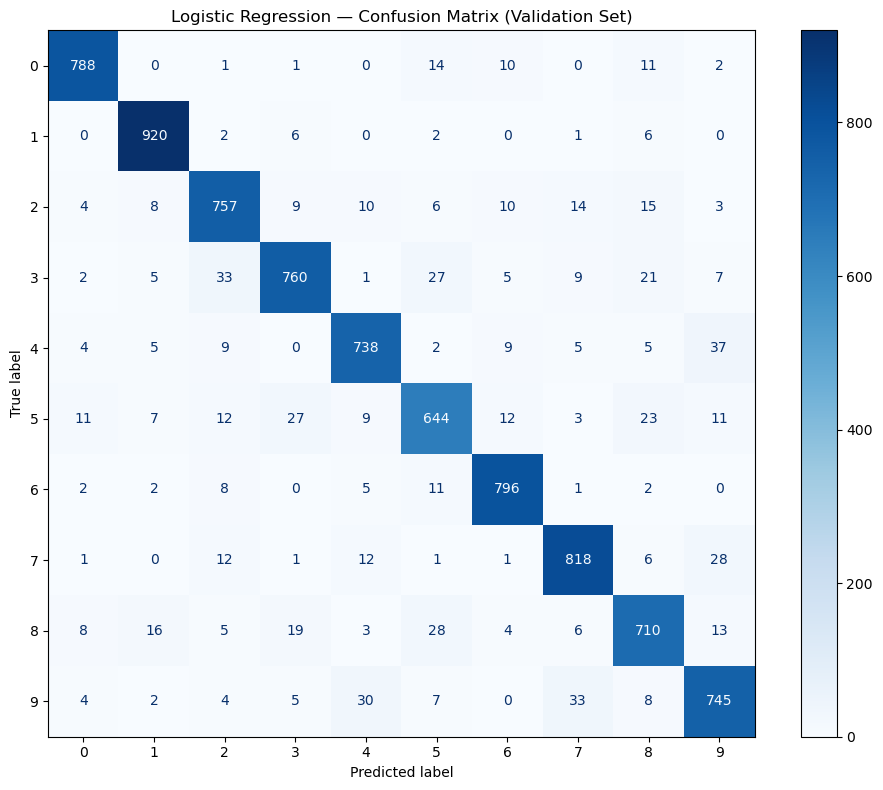

In [105]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_val, y_val_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=range(10))

fig, ax = plt.subplots(figsize=(10, 8))
disp.plot(ax=ax, colorbar=True, cmap='Blues')
ax.set_title("Logistic Regression — Confusion Matrix (Validation Set)")
plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'lr_confusion_matrix.pdf'), bbox_inches='tight')
plt.show()

Running t-SNE on validation set (this may take a minute)...


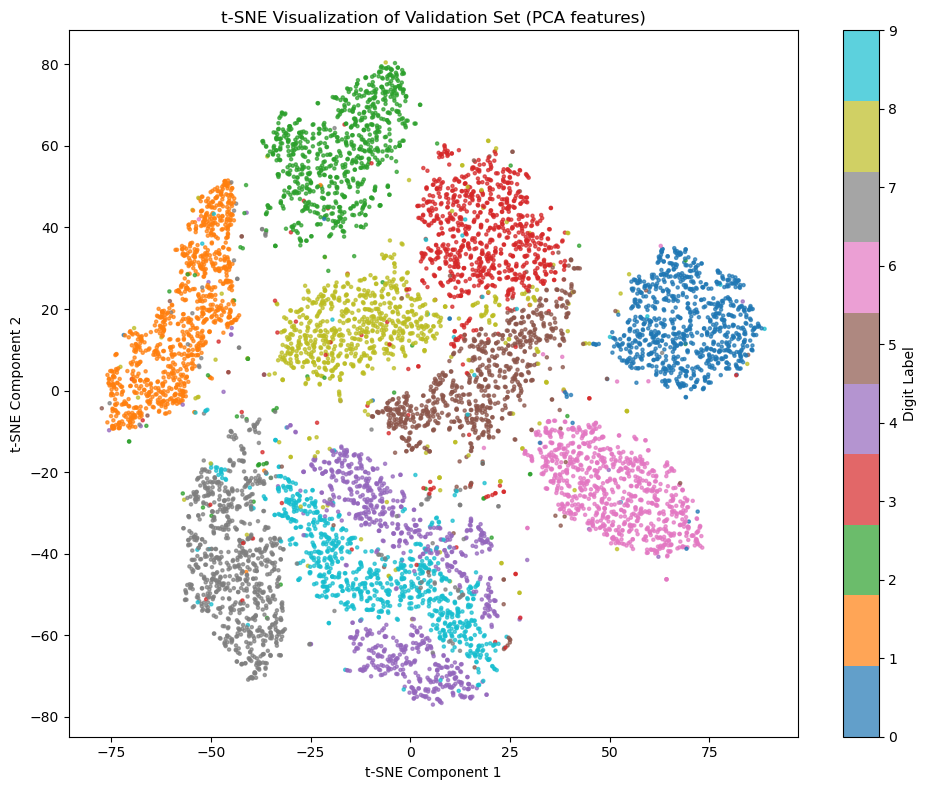

In [106]:
from sklearn.manifold import TSNE

print("Running t-SNE on validation set (this may take a minute)...")
tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000)
X_val_tsne = tsne.fit_transform(X_val)

fig, ax = plt.subplots(figsize=(10, 8))
scatter = ax.scatter(X_val_tsne[:, 0], X_val_tsne[:, 1], c=y_val.values, cmap='tab10', s=5, alpha=0.7)
cbar = fig.colorbar(scatter, ticks=range(10))
cbar.set_label('Digit Label')
ax.set_title("t-SNE Visualization of Validation Set (PCA features)")
ax.set_xlabel("t-SNE Component 1")
ax.set_ylabel("t-SNE Component 2")
plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'tsne_pca_val.pdf'), bbox_inches='tight')
plt.show()

#### Observations drawn from the confusion matrix for the Logistic Regression Method



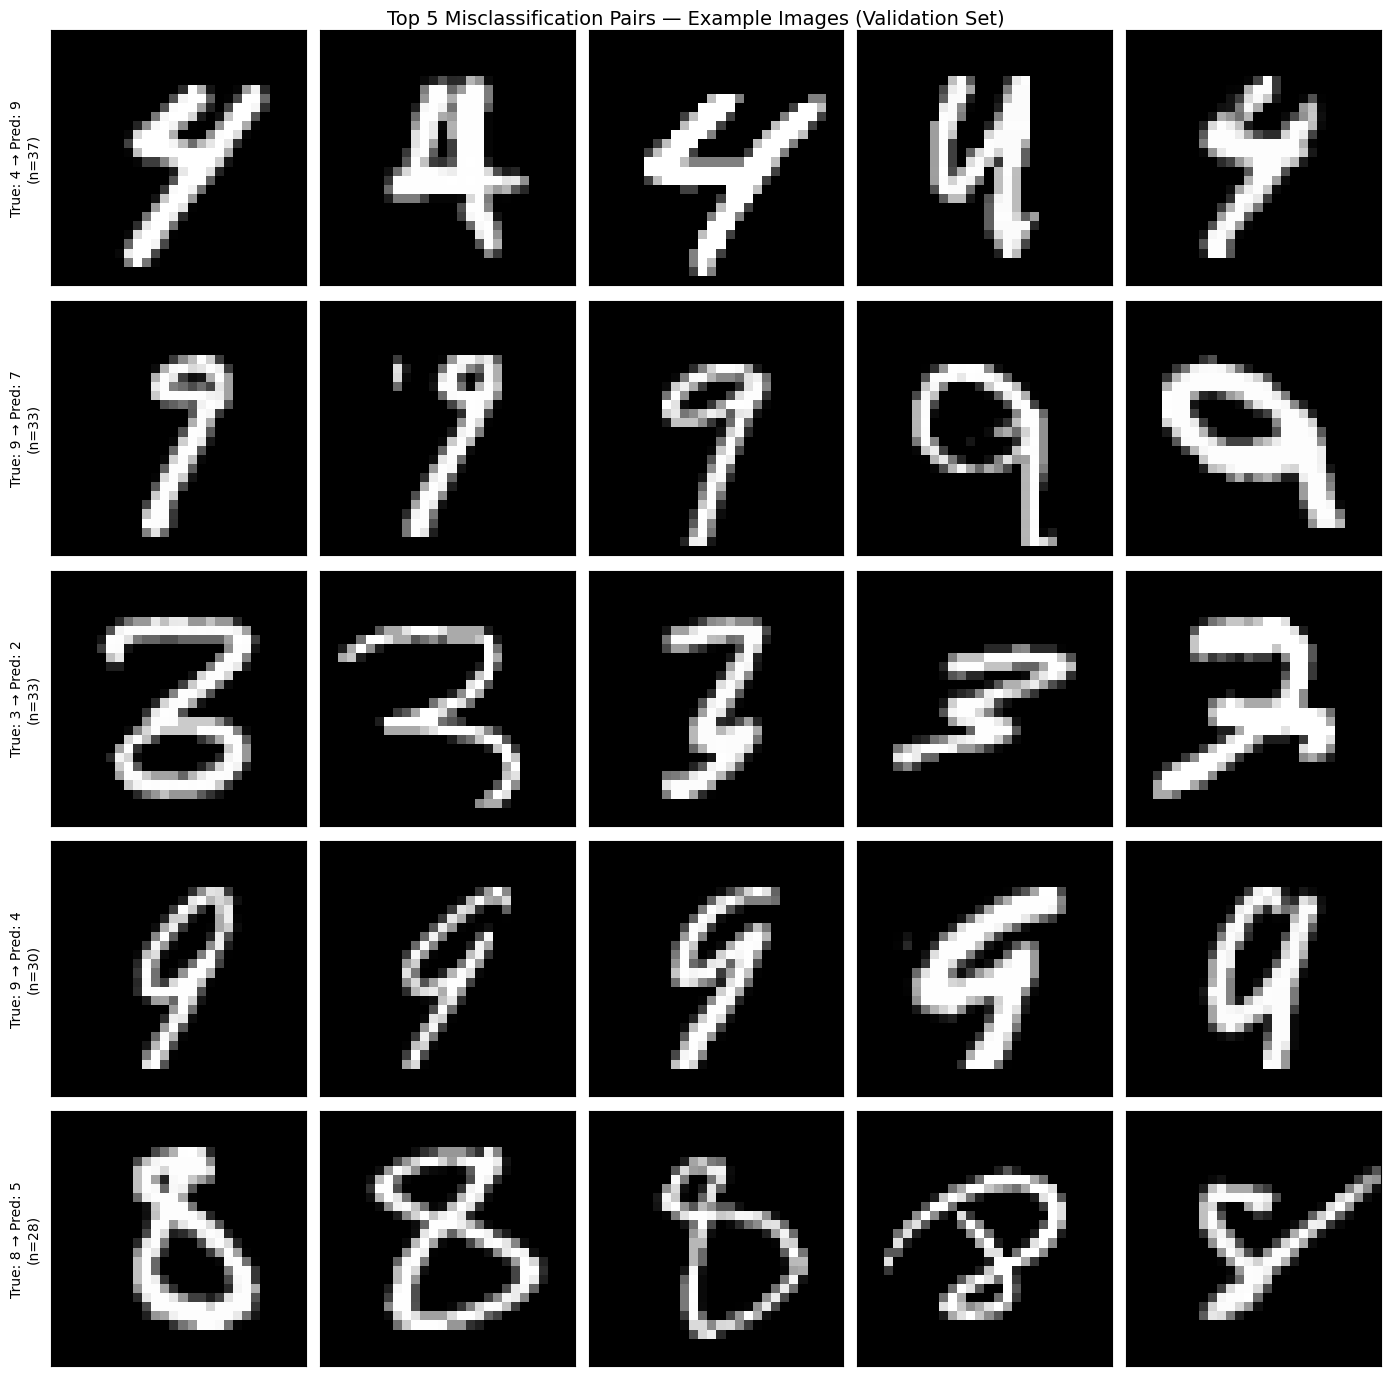

In [107]:
# Top 5 misclassified (true_label, predicted_label) pairs
cm_no_diag = cm.copy()
np.fill_diagonal(cm_no_diag, 0)

top5_flat = np.argsort(cm_no_diag.ravel())[::-1][:5]
top5_pairs = [(idx // 10, idx % 10) for idx in top5_flat]

val_indices  = y_val.index
X_val_images = X_scaled.loc[val_indices]

fig, axes = plt.subplots(5, 5, figsize=(14, 14))
fig.suptitle("Top 5 Misclassification Pairs — Example Images (Validation Set)", fontsize=14)

n_examples = 5
for row, (true_lbl, pred_lbl) in enumerate(top5_pairs):
    count = cm_no_diag[true_lbl, pred_lbl]
    mask = (y_val.values == true_lbl) & (y_val_pred == pred_lbl)
    matched_images = X_val_images.values[mask]

    for col in range(n_examples):
        ax = axes[row, col]
        if col < len(matched_images):
            ax.imshow(matched_images[col].reshape(28, 28), cmap='gray')
        else:
            ax.axis('off')
            continue
        if col == 0:
            ax.set_ylabel(f"True: {true_lbl} → Pred: {pred_lbl}\n(n={count})", fontsize=10, labelpad=8)
        ax.set_xticks([])
        ax.set_yticks([])

plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'lr_top5_misclassified.pdf'), bbox_inches='tight')
plt.show()

## Step 5: CNN with K-Fold Cross-Validation

We use the CNN architecture defined above with 5-fold cross-validation to get a robust estimate of generalisation performance, then report final accuracy on the held-out test set.

In [108]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import KFold, train_test_split
from sklearn.metrics import accuracy_score, classification_report

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

# ── Data ──────────────────────────────────────────────────────────────────────
X_np = X_scaled.values.astype(np.float32)
y_np = y.values.astype(np.int64)

# Hold out a fixed 20 % test set (never seen during CV)
X_trainval, X_test_cnn, y_trainval, y_test_cnn = train_test_split(
    X_np, y_np, test_size=0.2, random_state=42, stratify=y_np
)

# ── Helpers ───────────────────────────────────────────────────────────────────
def make_loader(X, y, batch_size=128, shuffle=True):
    ds = TensorDataset(torch.tensor(X), torch.tensor(y))
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle)

def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0
    for xb, yb in loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(xb)
    return total_loss / len(loader.dataset)

def evaluate(model, loader):
    model.eval()
    preds, targets = [], []
    with torch.no_grad():
        for xb, yb in loader:
            preds.extend(model(xb.to(DEVICE)).argmax(1).cpu().numpy())
            targets.extend(yb.numpy())
    return accuracy_score(targets, preds), np.array(preds), np.array(targets)

# ── K-Fold CV ─────────────────────────────────────────────────────────────────
K = 5
EPOCHS = 10
kf = KFold(n_splits=K, shuffle=True, random_state=42)

fold_val_accs = []

for fold, (train_idx, val_idx) in enumerate(kf.split(X_trainval)):
    print(f"\n── Fold {fold+1}/{K} ──")
    X_tr, X_vl = X_trainval[train_idx], X_trainval[val_idx]
    y_tr, y_vl = y_trainval[train_idx], y_trainval[val_idx]

    train_loader = make_loader(X_tr, y_tr)
    val_loader   = make_loader(X_vl, y_vl, shuffle=False)

    model     = CNN().to(DEVICE)
    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    criterion = nn.CrossEntropyLoss()

    for epoch in range(1, EPOCHS + 1):
        loss = train_one_epoch(model, train_loader, optimizer, criterion)
        if epoch % 2 == 0 or epoch == EPOCHS:
            val_acc, _, _ = evaluate(model, val_loader)
            print(f"  Epoch {epoch:2d}/{EPOCHS}  loss={loss:.4f}  val_acc={val_acc:.4f}")

    fold_val_acc, _, _ = evaluate(model, val_loader)
    fold_val_accs.append(fold_val_acc)
    print(f"  → Fold {fold+1} val accuracy: {fold_val_acc:.4f}")

print(f"\n{'='*50}")
print(f"CV Val Accuracy: {np.mean(fold_val_accs):.4f} ± {np.std(fold_val_accs):.4f}")
print(f"Per-fold:        {[f'{a:.4f}' for a in fold_val_accs]}")

Using device: cuda

── Fold 1/5 ──
  Epoch  2/10  loss=0.1300  val_acc=0.9771
  Epoch  4/10  loss=0.0704  val_acc=0.9810
  Epoch  6/10  loss=0.0471  val_acc=0.9851
  Epoch  8/10  loss=0.0366  val_acc=0.9875
  Epoch 10/10  loss=0.0262  val_acc=0.9872
  → Fold 1 val accuracy: 0.9872

── Fold 2/5 ──
  Epoch  2/10  loss=0.1135  val_acc=0.9775
  Epoch  4/10  loss=0.0557  val_acc=0.9836
  Epoch  6/10  loss=0.0371  val_acc=0.9838
  Epoch  8/10  loss=0.0301  val_acc=0.9851
  Epoch 10/10  loss=0.0240  val_acc=0.9847
  → Fold 2 val accuracy: 0.9847

── Fold 3/5 ──
  Epoch  2/10  loss=0.1255  val_acc=0.9790
  Epoch  4/10  loss=0.0653  val_acc=0.9818
  Epoch  6/10  loss=0.0469  val_acc=0.9871
  Epoch  8/10  loss=0.0339  val_acc=0.9868
  Epoch 10/10  loss=0.0258  val_acc=0.9900
  → Fold 3 val accuracy: 0.9900

── Fold 4/5 ──
  Epoch  2/10  loss=0.1219  val_acc=0.9790
  Epoch  4/10  loss=0.0608  val_acc=0.9821
  Epoch  6/10  loss=0.0450  val_acc=0.9854
  Epoch  8/10  loss=0.0364  val_acc=0.9868
  Ep

In [109]:
class CNN(nn.Module):
    """
    Simple CNN for MNIST digit classification.
    Accepts flat 784-dim input (rescaled pixels) and reshapes
    internally to 1×28×28 before the convolutional layers.
    """

    def __init__(self, output_dim: int = 10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),  # → 32×28×28
            nn.ReLU(),
            nn.MaxPool2d(2),                              # → 32×14×14
            nn.Conv2d(32, 64, kernel_size=3, padding=1), # → 64×14×14
            nn.ReLU(),
            nn.MaxPool2d(2),                              # → 64×7×7
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, output_dim),
        )

    def forward(self, x):
        x = x.view(-1, 1, 28, 28)  # reshape flat 784 → 1×28×28
        return self.classifier(self.features(x))

In [110]:
# ── Final model: retrain on full train+val, evaluate on held-out test ─────────
print("Retraining on full train+val set...")
final_loader = make_loader(X_trainval, y_trainval)
test_loader  = make_loader(X_test_cnn, y_test_cnn, shuffle=False)

final_model     = CNN().to(DEVICE)
final_optimizer = optim.Adam(final_model.parameters(), lr=1e-3)
criterion       = nn.CrossEntropyLoss()

for epoch in range(1, EPOCHS + 1):
    loss = train_one_epoch(final_model, final_loader, final_optimizer, criterion)
    if epoch % 2 == 0 or epoch == EPOCHS:
        print(f"  Epoch {epoch:2d}/{EPOCHS}  loss={loss:.4f}")

test_acc, y_test_pred_cnn, y_test_true_cnn = evaluate(final_model, test_loader)

print(f"\n{'='*50}")
print(f"CV Val Accuracy:  {np.mean(fold_val_accs):.4f} ± {np.std(fold_val_accs):.4f}")
print(f"Test Accuracy:    {test_acc:.4f} ({test_acc*100:.2f}%)")
print("\nClassification Report (Test Set):")
print(classification_report(y_test_true_cnn, y_test_pred_cnn))

# ── Save LaTeX tables ──────────────────────────────────────────────────────────
# CV fold summary
fold_rows = "\n".join(
    f"  Fold {i+1} & {acc:.4f} \\\\" for i, acc in enumerate(fold_val_accs)
)
cv_tex = (
    "\\begin{tabular}{lc}\n\\toprule\nFold & Val Accuracy \\\\\n\\midrule\n"
    + fold_rows + "\n\\midrule\n"
    f"  Mean $\\pm$ Std & ${np.mean(fold_val_accs):.4f} \\pm {np.std(fold_val_accs):.4f}$ \\\\\n"
    f"  Test Accuracy & {test_acc:.4f} \\\\\n"
    "\\bottomrule\n\\end{tabular}"
)
save_tex('cnn_cv_results.tex', cv_tex)

# Classification report
cnn_report = classification_report(y_test_true_cnn, y_test_pred_cnn, output_dict=True)
cr_rows = "\n".join(
    f"  {lbl} & {cnn_report[lbl]['precision']:.4f} & {cnn_report[lbl]['recall']:.4f} "
    f"& {cnn_report[lbl]['f1-score']:.4f} & {int(cnn_report[lbl]['support'])} \\\\"
    for lbl in [str(i) for i in range(10)]
)
cr_tex = (
    "\\begin{tabular}{lcccc}\n\\toprule\nClass & Precision & Recall & F1-Score & Support \\\\\n\\midrule\n"
    + cr_rows + "\n\\midrule\n"
    f"  macro avg & {cnn_report['macro avg']['precision']:.4f} & {cnn_report['macro avg']['recall']:.4f} "
    f"& {cnn_report['macro avg']['f1-score']:.4f} & {int(cnn_report['macro avg']['support'])} \\\\\n"
    f"  weighted avg & {cnn_report['weighted avg']['precision']:.4f} & {cnn_report['weighted avg']['recall']:.4f} "
    f"& {cnn_report['weighted avg']['f1-score']:.4f} & {int(cnn_report['weighted avg']['support'])} \\\\\n"
    f"\\midrule\n  Accuracy & \\multicolumn{{3}}{{c}}{{{test_acc:.4f}}} & {int(cnn_report['weighted avg']['support'])} \\\\\n"
    "\\bottomrule\n\\end{tabular}"
)
save_tex('cnn_classification_report.tex', cr_tex)

Retraining on full train+val set...
  Epoch  2/10  loss=0.1190
  Epoch  4/10  loss=0.0662
  Epoch  6/10  loss=0.0445
  Epoch  8/10  loss=0.0363
  Epoch 10/10  loss=0.0302

CV Val Accuracy:  0.9876 ± 0.0018
Test Accuracy:    0.9890 (98.90%)

Classification Report (Test Set):
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       827
           1       1.00      1.00      1.00       937
           2       0.98      1.00      0.99       835
           3       1.00      0.97      0.99       870
           4       0.98      1.00      0.99       814
           5       0.99      0.98      0.99       759
           6       0.99      0.99      0.99       827
           7       0.99      0.99      0.99       880
           8       0.98      0.98      0.98       813
           9       0.99      0.98      0.98       838

    accuracy                           0.99      8400
   macro avg       0.99      0.99      0.99      8400
weighted avg       0.

Extracted features shape: (6720, 3136)  (64×7×7 = 3136 dims)
Running t-SNE (this may take a minute)...


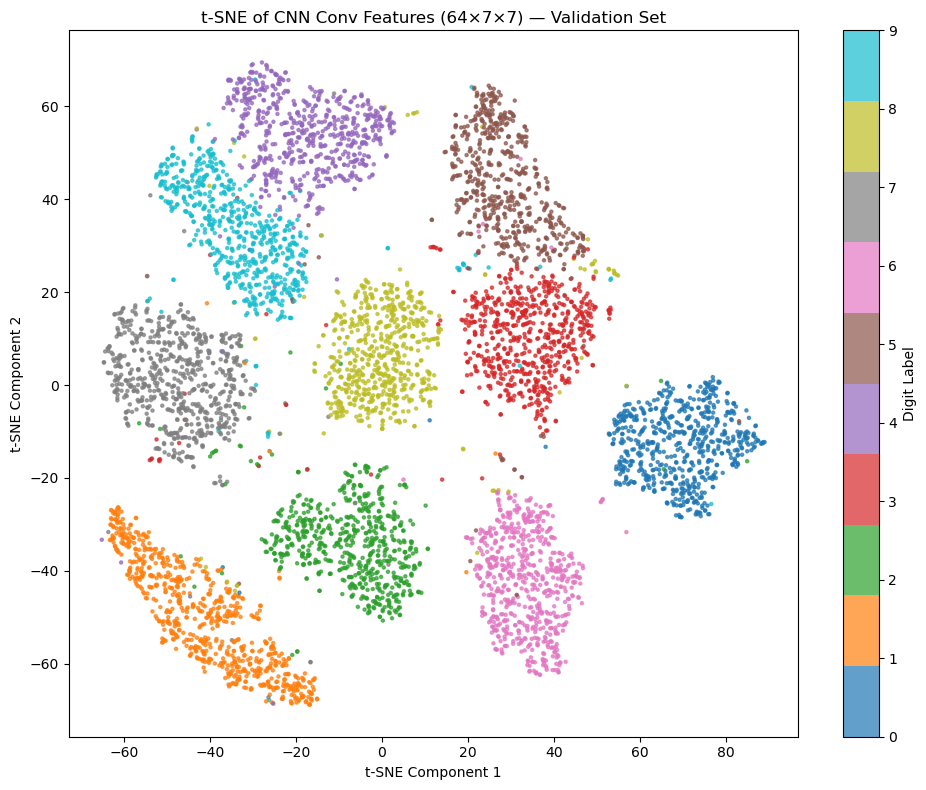

In [111]:
from sklearn.manifold import TSNE

# ── Build a val set from X_trainval (same 80/20 split) ───────────────────────
_, X_val_cnn, _, y_val_cnn = train_test_split(
    X_trainval, y_trainval, test_size=0.2, random_state=42, stratify=y_trainval
)
val_loader_cnn = make_loader(X_val_cnn, y_val_cnn, shuffle=False)

# ── Extract 64×7×7 flattened features from the trained CNN ───────────────────
final_model.eval()
cnn_features = []
cnn_labels   = []

with torch.no_grad():
    for xb, yb in val_loader_cnn:
        xb = xb.to(DEVICE)
        x = xb.view(-1, 1, 28, 28)
        x = final_model.features(x)
        x = x.flatten(1)
        cnn_features.append(x.cpu().numpy())
        cnn_labels.append(yb.numpy())

cnn_features = np.concatenate(cnn_features, axis=0)
cnn_labels   = np.concatenate(cnn_labels,   axis=0)
print(f"Extracted features shape: {cnn_features.shape}  (64×7×7 = 3136 dims)")

print("Running t-SNE (this may take a minute)...")
tsne_cnn = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000)
cnn_tsne_2d = tsne_cnn.fit_transform(cnn_features)

fig, ax = plt.subplots(figsize=(10, 8))
scatter = ax.scatter(cnn_tsne_2d[:, 0], cnn_tsne_2d[:, 1], c=cnn_labels, cmap='tab10', s=5, alpha=0.7)
cbar = fig.colorbar(scatter, ticks=range(10))
cbar.set_label('Digit Label')
ax.set_title("t-SNE of CNN Conv Features (64×7×7) — Validation Set")
ax.set_xlabel("t-SNE Component 1")
ax.set_ylabel("t-SNE Component 2")
plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'tsne_cnn_val.pdf'), bbox_inches='tight')
plt.show()

## Ablation: Does Depth Matter? (Remove Second Conv Block)

We define a shallow CNN with only one conv block (`Conv2d 1→32` + `MaxPool`) and compare its 5-fold CV accuracy against the full two-block CNN.

In [112]:
class CNNShallow(nn.Module):
    """Single conv block ablation — removes the second Conv2d(32→64) block."""

    def __init__(self, output_dim: int = 10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),  # → 32×28×28
            nn.ReLU(),
            nn.MaxPool2d(2),                              # → 32×14×14
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 14 * 14, 128),                # 6272 → 128
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, output_dim),
        )

    def forward(self, x):
        x = x.view(-1, 1, 28, 28)
        return self.classifier(self.features(x))


# ── K-Fold CV for CNNShallow ──────────────────────────────────────────────────
print("Running 5-fold CV on CNNShallow...")
shallow_fold_accs = []

for fold, (train_idx, val_idx) in enumerate(kf.split(X_trainval)):
    print(f"\n── Fold {fold+1}/{K} ──")
    X_tr, X_vl = X_trainval[train_idx], X_trainval[val_idx]
    y_tr, y_vl = y_trainval[train_idx], y_trainval[val_idx]

    train_loader = make_loader(X_tr, y_tr)
    val_loader   = make_loader(X_vl, y_vl, shuffle=False)

    model     = CNNShallow().to(DEVICE)
    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    criterion = nn.CrossEntropyLoss()

    for epoch in range(1, EPOCHS + 1):
        loss = train_one_epoch(model, train_loader, optimizer, criterion)
        if epoch % 2 == 0 or epoch == EPOCHS:
            val_acc, _, _ = evaluate(model, val_loader)
            print(f"  Epoch {epoch:2d}/{EPOCHS}  loss={loss:.4f}  val_acc={val_acc:.4f}")

    fold_acc, _, _ = evaluate(model, val_loader)
    shallow_fold_accs.append(fold_acc)
    print(f"  → Fold {fold+1} val accuracy: {fold_acc:.4f}")

print(f"\n{'='*50}")
print(f"CNNShallow  CV: {np.mean(shallow_fold_accs):.4f} ± {np.std(shallow_fold_accs):.4f}")
print(f"CNN (full)  CV: {np.mean(fold_val_accs):.4f} ± {np.std(fold_val_accs):.4f}")


# ── Final model: retrain shallow CNN on full trainval, report test accuracy ───
print("\nRetraining CNNShallow on full train+val set...")
shallow_final = CNNShallow().to(DEVICE)
shallow_opt   = optim.Adam(shallow_final.parameters(), lr=1e-3)

for epoch in range(1, EPOCHS + 1):
    train_one_epoch(shallow_final, make_loader(X_trainval, y_trainval), shallow_opt, criterion)

shallow_test_acc, y_shallow_pred, y_shallow_true = evaluate(shallow_final, test_loader)
print(f"\nTest Accuracy — CNNShallow:  {shallow_test_acc:.4f} ({shallow_test_acc*100:.2f}%)")
print(f"Test Accuracy — CNN (full):  {test_acc:.4f} ({test_acc*100:.2f}%)")
print(f"\nClassification Report (CNNShallow, Test Set):")
print(classification_report(y_shallow_true, y_shallow_pred))

Running 5-fold CV on CNNShallow...

── Fold 1/5 ──
  Epoch  2/10  loss=0.2043  val_acc=0.9629
  Epoch  4/10  loss=0.1072  val_acc=0.9762
  Epoch  6/10  loss=0.0711  val_acc=0.9808
  Epoch  8/10  loss=0.0544  val_acc=0.9820
  Epoch 10/10  loss=0.0421  val_acc=0.9844
  → Fold 1 val accuracy: 0.9844

── Fold 2/5 ──
  Epoch  2/10  loss=0.2329  val_acc=0.9536
  Epoch  4/10  loss=0.1260  val_acc=0.9708
  Epoch  6/10  loss=0.0850  val_acc=0.9725
  Epoch  8/10  loss=0.0666  val_acc=0.9751
  Epoch 10/10  loss=0.0518  val_acc=0.9793
  → Fold 2 val accuracy: 0.9793

── Fold 3/5 ──
  Epoch  2/10  loss=0.1844  val_acc=0.9693
  Epoch  4/10  loss=0.0891  val_acc=0.9793
  Epoch  6/10  loss=0.0629  val_acc=0.9829
  Epoch  8/10  loss=0.0444  val_acc=0.9865
  Epoch 10/10  loss=0.0334  val_acc=0.9863
  → Fold 3 val accuracy: 0.9863

── Fold 4/5 ──
  Epoch  2/10  loss=0.2128  val_acc=0.9560
  Epoch  4/10  loss=0.1094  val_acc=0.9749
  Epoch  6/10  loss=0.0737  val_acc=0.9753
  Epoch  8/10  loss=0.0548  val

In [113]:
class CNNShallowLinear(nn.Module):
    """Ablation: single conv block + direct linear probe (no hidden layer)."""

    def __init__(self, output_dim: int = 10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),  # → 32×28×28
            nn.ReLU(),
            nn.MaxPool2d(2),                              # → 32×14×14
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 14 * 14, output_dim),         # 6272 → 10 directly
        )

    def forward(self, x):
        x = x.view(-1, 1, 28, 28)
        return self.classifier(self.features(x))


# ── K-Fold CV for CNNShallowLinear ───────────────────────────────────────────
print("Running 5-fold CV on CNNShallowLinear...")
shallow_linear_fold_accs = []

for fold, (train_idx, val_idx) in enumerate(kf.split(X_trainval)):
    print(f"\n── Fold {fold+1}/{K} ──")
    X_tr, X_vl = X_trainval[train_idx], X_trainval[val_idx]
    y_tr, y_vl = y_trainval[train_idx], y_trainval[val_idx]

    train_loader = make_loader(X_tr, y_tr)
    val_loader   = make_loader(X_vl, y_vl, shuffle=False)

    model     = CNNShallowLinear().to(DEVICE)
    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    criterion = nn.CrossEntropyLoss()

    for epoch in range(1, EPOCHS + 1):
        loss = train_one_epoch(model, train_loader, optimizer, criterion)
        if epoch % 2 == 0 or epoch == EPOCHS:
            val_acc, _, _ = evaluate(model, val_loader)
            print(f"  Epoch {epoch:2d}/{EPOCHS}  loss={loss:.4f}  val_acc={val_acc:.4f}")

    fold_acc, _, _ = evaluate(model, val_loader)
    shallow_linear_fold_accs.append(fold_acc)
    print(f"  → Fold {fold+1} val accuracy: {fold_acc:.4f}")

# ── Final model ───────────────────────────────────────────────────────────────
print("\nRetraining CNNShallowLinear on full train+val set...")
sl_final  = CNNShallowLinear().to(DEVICE)
sl_opt    = optim.Adam(sl_final.parameters(), lr=1e-3)

for epoch in range(1, EPOCHS + 1):
    train_one_epoch(sl_final, make_loader(X_trainval, y_trainval), sl_opt, criterion)

sl_test_acc, y_sl_pred, y_sl_true = evaluate(sl_final, test_loader)

# ── Summary table (all three depth variants) ──────────────────────────────────
print(f"\n{'='*60}")
print(f"{'Model':<22} {'CV Acc (mean±std)':<24} {'Test Acc'}")
print(f"{'-'*60}")
print(f"{'CNN (full)':<22} {np.mean(fold_val_accs):.4f} ± {np.std(fold_val_accs):.4f}          {test_acc:.4f}")
print(f"{'CNNShallow':<22} {np.mean(shallow_fold_accs):.4f} ± {np.std(shallow_fold_accs):.4f}          {shallow_test_acc:.4f}")
print(f"{'CNNShallowLinear':<22} {np.mean(shallow_linear_fold_accs):.4f} ± {np.std(shallow_linear_fold_accs):.4f}          {sl_test_acc:.4f}")
print(f"{'='*60}")

print("\nClassification Report (CNNShallowLinear, Test Set):")
print(classification_report(y_sl_true, y_sl_pred))

# ── Save LaTeX depth ablation table ───────────────────────────────────────────
models = [
    ("CNN (full)",        fold_val_accs,              test_acc),
    ("CNNShallow",        shallow_fold_accs,          shallow_test_acc),
    ("CNNShallowLinear",  shallow_linear_fold_accs,   sl_test_acc),
]
depth_rows = "\n".join(
    f"  {name} & ${np.mean(accs):.4f} \\pm {np.std(accs):.4f}$ & {t:.4f} \\\\"
    for name, accs, t in models
)
depth_tex = (
    "\\begin{tabular}{lcc}\n\\toprule\n"
    "Model & CV Val Accuracy (mean $\\pm$ std) & Test Accuracy \\\\\n\\midrule\n"
    + depth_rows + "\n\\bottomrule\n\\end{tabular}"
)
save_tex('depth_ablation.tex', depth_tex)

Running 5-fold CV on CNNShallowLinear...

── Fold 1/5 ──
  Epoch  2/10  loss=0.1639  val_acc=0.9595
  Epoch  4/10  loss=0.0839  val_acc=0.9743
  Epoch  6/10  loss=0.0591  val_acc=0.9769
  Epoch  8/10  loss=0.0449  val_acc=0.9774
  Epoch 10/10  loss=0.0373  val_acc=0.9787
  → Fold 1 val accuracy: 0.9787

── Fold 2/5 ──
  Epoch  2/10  loss=0.1741  val_acc=0.9540
  Epoch  4/10  loss=0.0886  val_acc=0.9674
  Epoch  6/10  loss=0.0621  val_acc=0.9717
  Epoch  8/10  loss=0.0478  val_acc=0.9723
  Epoch 10/10  loss=0.0391  val_acc=0.9734
  → Fold 2 val accuracy: 0.9734

── Fold 3/5 ──
  Epoch  2/10  loss=0.1820  val_acc=0.9609
  Epoch  4/10  loss=0.0926  val_acc=0.9723
  Epoch  6/10  loss=0.0635  val_acc=0.9778
  Epoch  8/10  loss=0.0493  val_acc=0.9771
  Epoch 10/10  loss=0.0401  val_acc=0.9781
  → Fold 3 val accuracy: 0.9781

── Fold 4/5 ──
  Epoch  2/10  loss=0.1669  val_acc=0.9597
  Epoch  4/10  loss=0.0830  val_acc=0.9734
  Epoch  6/10  loss=0.0586  val_acc=0.9769
  Epoch  8/10  loss=0.043

## Ablation: Learning Rate Sensitivity (CNN Full Model)

We sweep learning rates `{1e-2, 1e-3, 1e-4}` using 5-fold CV on the full CNN to understand how sensitive training is to this hyperparameter.


Learning rate: 0.01

  ── Fold 1/5 ──
    Epoch  2/10  loss=0.2114  val_acc=0.9568
    Epoch  4/10  loss=0.1411  val_acc=0.9628
    Epoch  6/10  loss=0.1197  val_acc=0.9689
    Epoch  8/10  loss=0.1062  val_acc=0.9719
    Epoch 10/10  loss=0.0982  val_acc=0.9682
  → Fold 1 val accuracy: 0.9682

  ── Fold 2/5 ──
    Epoch  2/10  loss=0.1559  val_acc=0.9677
    Epoch  4/10  loss=0.1108  val_acc=0.9725
    Epoch  6/10  loss=0.0949  val_acc=0.9805
    Epoch  8/10  loss=0.0903  val_acc=0.9774
    Epoch 10/10  loss=0.0807  val_acc=0.9780
  → Fold 2 val accuracy: 0.9780

  ── Fold 3/5 ──
    Epoch  2/10  loss=2.3018  val_acc=0.1146
    Epoch  4/10  loss=2.3017  val_acc=0.1042
    Epoch  6/10  loss=2.3019  val_acc=0.1146
    Epoch  8/10  loss=2.3019  val_acc=0.1146
    Epoch 10/10  loss=2.3020  val_acc=0.1146
  → Fold 3 val accuracy: 0.1146

  ── Fold 4/5 ──
    Epoch  2/10  loss=0.0862  val_acc=0.9793
    Epoch  4/10  loss=0.0560  val_acc=0.9826
    Epoch  6/10  loss=0.0443  val_acc=0.9841
 

/tmp/ipykernel_3879042/4188105711.py:54: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot(


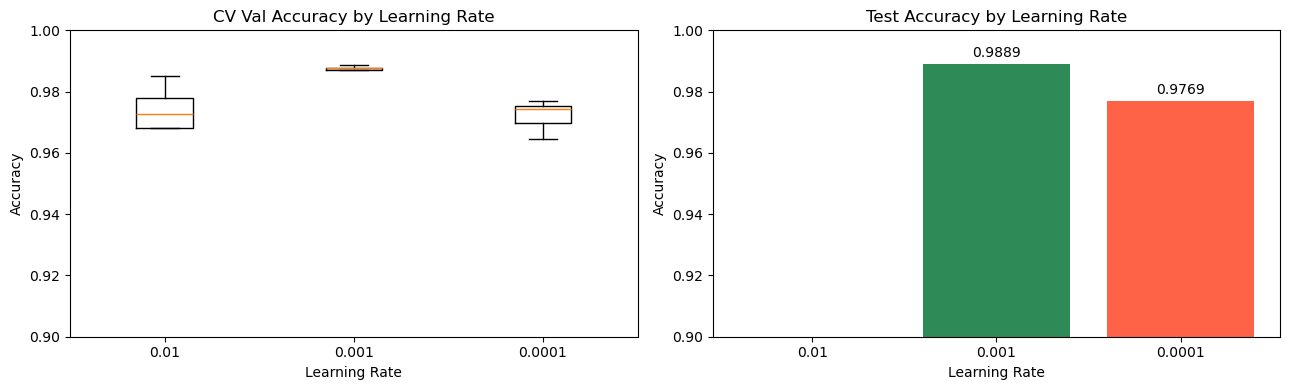

Saved TeX: /home/priyank1/FOML/project/FOML/report/final_tex/lr_sensitivity.tex


In [114]:
LEARNING_RATES = [1e-2, 1e-3, 1e-4]
lr_results = {}  # lr → {fold_accs, test_acc}

for lr in LEARNING_RATES:
    print(f"\n{'='*50}")
    print(f"Learning rate: {lr}")
    fold_accs = []

    for fold, (train_idx, val_idx) in enumerate(kf.split(X_trainval)):
        print(f"\n  ── Fold {fold+1}/{K} ──")
        X_tr, X_vl = X_trainval[train_idx], X_trainval[val_idx]
        y_tr, y_vl = y_trainval[train_idx], y_trainval[val_idx]

        train_loader = make_loader(X_tr, y_tr)
        val_loader   = make_loader(X_vl, y_vl, shuffle=False)

        model     = CNN().to(DEVICE)
        optimizer = optim.Adam(model.parameters(), lr=lr)
        criterion = nn.CrossEntropyLoss()

        for epoch in range(1, EPOCHS + 1):
            loss = train_one_epoch(model, train_loader, optimizer, criterion)
            if epoch % 2 == 0 or epoch == EPOCHS:
                val_acc, _, _ = evaluate(model, val_loader)
                print(f"    Epoch {epoch:2d}/{EPOCHS}  loss={loss:.4f}  val_acc={val_acc:.4f}")

        fold_acc, _, _ = evaluate(model, val_loader)
        fold_accs.append(fold_acc)
        print(f"  → Fold {fold+1} val accuracy: {fold_acc:.4f}")

    print(f"\n  Retraining lr={lr} on full train+val...")
    final_m   = CNN().to(DEVICE)
    final_opt = optim.Adam(final_m.parameters(), lr=lr)
    for epoch in range(1, EPOCHS + 1):
        train_one_epoch(final_m, make_loader(X_trainval, y_trainval), final_opt, criterion)

    t_acc, _, _ = evaluate(final_m, test_loader)
    lr_results[lr] = {"fold_accs": fold_accs, "test_acc": t_acc}
    print(f"  Test Accuracy (lr={lr}): {t_acc:.4f}")

# ── Summary table ─────────────────────────────────────────────────────────────
print(f"\n{'='*60}")
print(f"{'Learning Rate':<16} {'CV Acc (mean±std)':<26} {'Test Acc'}")
print(f"{'-'*60}")
for lr, res in lr_results.items():
    mean = np.mean(res['fold_accs'])
    std  = np.std(res['fold_accs'])
    print(f"{str(lr):<16} {mean:.4f} ± {std:.4f}              {res['test_acc']:.4f}")
print(f"{'='*60}")

# ── Plots ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].boxplot(
    [lr_results[lr]['fold_accs'] for lr in LEARNING_RATES],
    labels=[str(lr) for lr in LEARNING_RATES]
)
axes[0].set_title("CV Val Accuracy by Learning Rate")
axes[0].set_xlabel("Learning Rate")
axes[0].set_ylabel("Accuracy")
axes[0].set_ylim(0.9, 1.0)

test_accs = [lr_results[lr]['test_acc'] for lr in LEARNING_RATES]
bars = axes[1].bar([str(lr) for lr in LEARNING_RATES], test_accs, color=['steelblue', 'seagreen', 'tomato'])
axes[1].bar_label(bars, fmt='%.4f', padding=3)
axes[1].set_title("Test Accuracy by Learning Rate")
axes[1].set_xlabel("Learning Rate")
axes[1].set_ylabel("Accuracy")
axes[1].set_ylim(0.9, 1.0)

plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'lr_sensitivity.pdf'), bbox_inches='tight')
plt.show()

# ── Save LaTeX table ───────────────────────────────────────────────────────────
lr_rows = "\n".join(
    f"  {lr} & ${np.mean(res['fold_accs']):.4f} \\pm {np.std(res['fold_accs']):.4f}$ & {res['test_acc']:.4f} \\\\"
    for lr, res in lr_results.items()
)
lr_tex = (
    "\\begin{tabular}{lcc}\n\\toprule\n"
    "Learning Rate & CV Val Accuracy (mean $\\pm$ std) & Test Accuracy \\\\\n\\midrule\n"
    + lr_rows + "\n\\bottomrule\n\\end{tabular}"
)
save_tex('lr_sensitivity.tex', lr_tex)

## Ablation: Batch Size Sensitivity (CNN Full Model)

We sweep batch sizes `{64, 128, 256}` using 5-fold CV on the full CNN. To observe convergence behaviour, we also track per-epoch training loss for each batch size.


Batch size: 64

  ── Fold 1/5 ──
    Epoch  2/10  loss=0.1009  val_acc=0.9796
    Epoch  4/10  loss=0.0527  val_acc=0.9845
    Epoch  6/10  loss=0.0358  val_acc=0.9874
    Epoch  8/10  loss=0.0277  val_acc=0.9874
    Epoch 10/10  loss=0.0214  val_acc=0.9888
  → Fold 1 val accuracy: 0.9888

  ── Fold 2/5 ──
    Epoch  2/10  loss=0.0980  val_acc=0.9771
    Epoch  4/10  loss=0.0552  val_acc=0.9815
    Epoch  6/10  loss=0.0377  val_acc=0.9833
    Epoch  8/10  loss=0.0276  val_acc=0.9866
    Epoch 10/10  loss=0.0241  val_acc=0.9872
  → Fold 2 val accuracy: 0.9872

  ── Fold 3/5 ──
    Epoch  2/10  loss=0.0954  val_acc=0.9836
    Epoch  4/10  loss=0.0532  val_acc=0.9881
    Epoch  6/10  loss=0.0361  val_acc=0.9885
    Epoch  8/10  loss=0.0283  val_acc=0.9887
    Epoch 10/10  loss=0.0227  val_acc=0.9900
  → Fold 3 val accuracy: 0.9900

  ── Fold 4/5 ──
    Epoch  2/10  loss=0.1101  val_acc=0.9744
    Epoch  4/10  loss=0.0579  val_acc=0.9830
    Epoch  6/10  loss=0.0403  val_acc=0.9862
    Ep

/tmp/ipykernel_3879042/3575040650.py:68: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(


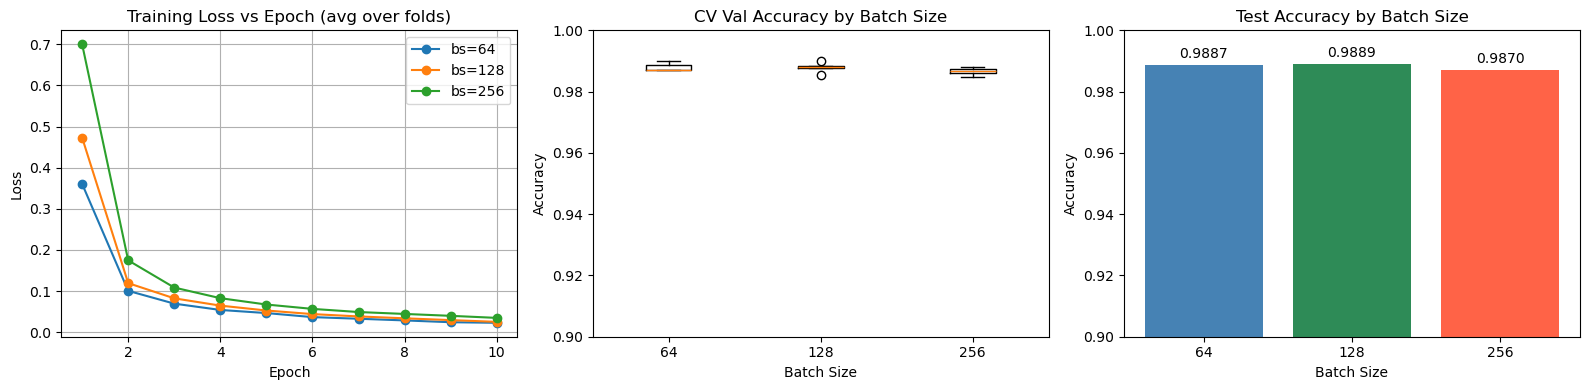

Saved TeX: /home/priyank1/FOML/project/FOML/report/final_tex/bs_ablation.tex


In [115]:
BATCH_SIZES = [64, 128, 256]
bs_results  = {}

for bs in BATCH_SIZES:
    print(f"\n{'='*50}")
    print(f"Batch size: {bs}")
    fold_accs         = []
    fold_epoch_losses = np.zeros((K, EPOCHS))

    for fold, (train_idx, val_idx) in enumerate(kf.split(X_trainval)):
        print(f"\n  ── Fold {fold+1}/{K} ──")
        X_tr, X_vl = X_trainval[train_idx], X_trainval[val_idx]
        y_tr, y_vl = y_trainval[train_idx], y_trainval[val_idx]

        train_loader = make_loader(X_tr, y_tr, batch_size=bs)
        val_loader   = make_loader(X_vl, y_vl, batch_size=bs, shuffle=False)

        model     = CNN().to(DEVICE)
        optimizer = optim.Adam(model.parameters(), lr=1e-3)
        criterion = nn.CrossEntropyLoss()

        for epoch in range(1, EPOCHS + 1):
            loss = train_one_epoch(model, train_loader, optimizer, criterion)
            fold_epoch_losses[fold, epoch - 1] = loss
            if epoch % 2 == 0 or epoch == EPOCHS:
                val_acc, _, _ = evaluate(model, val_loader)
                print(f"    Epoch {epoch:2d}/{EPOCHS}  loss={loss:.4f}  val_acc={val_acc:.4f}")

        fold_acc, _, _ = evaluate(model, val_loader)
        fold_accs.append(fold_acc)
        print(f"  → Fold {fold+1} val accuracy: {fold_acc:.4f}")

    print(f"\n  Retraining bs={bs} on full train+val...")
    final_m   = CNN().to(DEVICE)
    final_opt = optim.Adam(final_m.parameters(), lr=1e-3)
    for epoch in range(1, EPOCHS + 1):
        train_one_epoch(final_m, make_loader(X_trainval, y_trainval, batch_size=bs), final_opt, criterion)

    t_acc, _, _ = evaluate(final_m, test_loader)
    bs_results[bs] = {
        "fold_accs":    fold_accs,
        "test_acc":     t_acc,
        "epoch_losses": fold_epoch_losses.mean(axis=0),
    }
    print(f"  Test Accuracy (bs={bs}): {t_acc:.4f}")

# ── Summary table ─────────────────────────────────────────────────────────────
print(f"\n{'='*60}")
print(f"{'Batch Size':<14} {'CV Acc (mean±std)':<26} {'Test Acc'}")
print(f"{'-'*60}")
for bs, res in bs_results.items():
    mean = np.mean(res['fold_accs'])
    std  = np.std(res['fold_accs'])
    print(f"{str(bs):<14} {mean:.4f} ± {std:.4f}              {res['test_acc']:.4f}")
print(f"{'='*60}")

# ── Plots ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for bs, res in bs_results.items():
    axes[0].plot(range(1, EPOCHS + 1), res['epoch_losses'], marker='o', label=f"bs={bs}")
axes[0].set_title("Training Loss vs Epoch (avg over folds)")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True)

axes[1].boxplot(
    [bs_results[bs]['fold_accs'] for bs in BATCH_SIZES],
    labels=[str(bs) for bs in BATCH_SIZES]
)
axes[1].set_title("CV Val Accuracy by Batch Size")
axes[1].set_xlabel("Batch Size")
axes[1].set_ylabel("Accuracy")
axes[1].set_ylim(0.9, 1.0)

test_accs = [bs_results[bs]['test_acc'] for bs in BATCH_SIZES]
bars = axes[2].bar([str(bs) for bs in BATCH_SIZES], test_accs, color=['steelblue', 'seagreen', 'tomato'])
axes[2].bar_label(bars, fmt='%.4f', padding=3)
axes[2].set_title("Test Accuracy by Batch Size")
axes[2].set_xlabel("Batch Size")
axes[2].set_ylabel("Accuracy")
axes[2].set_ylim(0.9, 1.0)

plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'bs_ablation.pdf'), bbox_inches='tight')
plt.show()

# ── Save LaTeX table ───────────────────────────────────────────────────────────
bs_rows = "\n".join(
    f"  {bs} & ${np.mean(res['fold_accs']):.4f} \\pm {np.std(res['fold_accs']):.4f}$ & {res['test_acc']:.4f} \\\\"
    for bs, res in bs_results.items()
)
bs_tex = (
    "\\begin{tabular}{lcc}\n\\toprule\n"
    "Batch Size & CV Val Accuracy (mean $\\pm$ std) & Test Accuracy \\\\\n\\midrule\n"
    + bs_rows + "\n\\bottomrule\n\\end{tabular}"
)
save_tex('bs_ablation.tex', bs_tex)